# Proyecto CallMeMaybe: Análisis de Eficiencia de Operadores

**0. Introducción**

- Contexto del Negocio
- Datos Utilizados
- Objetivos Específicos
- Estructura del Análisis

**1. Preprocesamiento de Datos**

*1.1  Análisis Inicial*

- Revisar tipos de datos y valores faltantes
- Identificar duplicados
- Verificar consistencia entre datasets


*1.2  Limpieza*
- Estandarizar fechas
- Tratar valores nulos
- Eliminar duplicados si existen


*1.3  Preparación*
- Calcular tiempo de espera por llamada
- Identificar llamadas perdidas por operador
- Clasificar llamadas por tipo

*1.4  Conclusiones del Preprocesamiento*


**2. Análisis Exploratorio de Datos**

*2.1  Análisis General*
- Distribución de tipos de llamadas
- Patrones temporales de llamadas
- Estadísticas generales de duración y espera

*2.2  Análisis por Operador*
- Volumen de llamadas por operador
- Tasa de llamadas perdidas
- Tiempo promedio de espera
- Cantidad de llamadas salientes

*2.3  Conclusiones del Análisis Exploratorio*


**3. Análisis de Eficiencia**

*3.1  Métricas por Operador*
- Porcentaje de llamadas perdidas
- Promedio de tiempo de espera
- Total de llamadas atendidas
- Proporción de llamadas entrantes/salientes

*3.2  Análisis Temporal*
- Distribución diaria de llamadas
- Variación en llamadas perdidas
- Patrones de tiempo de espera

*3.3 Conclusiones del Análisis de Métricas de Desempeño y Patrones Temporales*


**4. Identificación de Ineficiencia**

*4.1  Análisis Estadístico*
- Calcular medias y desviaciones de métricas clave
- Identificar valores atípicos
- Establecer umbrales basados en datos

*4.2  Evaluación*
- Clasificar operadores según métricas
- Identificar casos problemáticos
- Validar consistencia de resultados

*4.3  Conclusiones de la identificación de ineficiencia*


**5. Resultados y Visualizaciones**

*5.1  Hallazgos*
- Lista de operadores ineficaces
- Resumen de métricas principales
- Patrones identificados

*5.2  Visualizaciones*
- Gráficos de desempeño por operador
- Distribución temporal de métricas
- Comparativas entre operadores

*5.3 Conclusiones del Análisis Visual y Hallazgos Principales*



**6. Conclusiones Generales del Proyecto**
- Cumplimiento de Objetivos
- Alcance del análisis
- Consideraciones de los datos
- Recomendaciones


**0.Introducción**

Este proyecto tiene como objetivo analizar la eficiencia de los operadores del servicio de telefonía virtual CallMeMaybe, para identificar aquellos que presentan un desempeño ineficaz. El análisis se basa en datos de llamadas y clientes, evaluando métricas clave como llamadas perdidas, tiempos de espera y volumen de llamadas.

*Contexto del Negocio*
CallMeMaybe es un servicio que permite a organizaciones distribuir llamadas entrantes entre operadores, gestionar llamadas salientes y facilitar comunicación interna. Se considera que un operador es ineficaz si presenta:
- Gran cantidad de llamadas entrantes perdidas (internas y externas)
- Tiempo de espera prolongado para llamadas entrantes
- Bajo número de llamadas salientes cuando corresponde

*Datos Utilizados*
- telecom_dataset_us.csv**: Contiene la información detallada de las llamadas
  - Registros de llamadas y métricas operativas
  - Incluye: ID usuario, fecha, tipo llamada, operador, duración, estado

- telecom_clients_us.csv**: Contiene información de los clientes
  - Información básica de clientes
  - Contiene: ID usuario, plan tarifario, fecha registro

*Objetivos Específicos*
- Identificar operadores con alta tasa de llamadas perdidas
- Analizar tiempos de espera prolongados
- Evaluar el balance entre llamadas entrantes y salientes
- Proporcionar recomendaciones basadas en datos para mejoras operativas


*Estructura del Análisis*

El análisis se desarrollará en cinco etapas principales:

1. **Preprocesamiento de Datos**: Limpieza y preparación inicial de los datos
2. **Análisis Exploratorio**: Comprensión de patrones y distribuciones
3. **Análisis de Eficiencia**: Evaluación de métricas de desempeño
4. **Identificación de Ineficiencia**: Detección de operadores con bajo rendimiento
5. **Resultados y Visualizaciones**: Presentación de hallazgos y recomendaciones


## Preprocesamiento de Datos

### Análisis Inicial

Primero importamos las librerías necesarias y cargamos los datos:

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Lectura de datasets
telecom_data = pd.read_csv('/datasets/telecom_dataset_us.csv')
client_data = pd.read_csv('/datasets/telecom_clients_us.csv')

#### Revisión de tipos de datos y valores faltantes

Analizaremos la estructura y calidad de ambos datasets:

In [2]:
# Análisis del dataset de telecomunicaciones
print("=== Dataset de Telecomunicaciones ===")
print("\nInformación de tipos de datos:")
print(telecom_data.info())
print("\nValores faltantes:")
print(telecom_data.isnull().sum())
print("\nPrimeras 5 filas:")
print(telecom_data.head())

# Análisis del dataset de clientes
print("\n=== Dataset de Clientes ===")
print("\nInformación de tipos de datos:")
print(client_data.info())
print("\nValores faltantes:")
print(client_data.isnull().sum())
print("\nPrimeras 5 filas:")
print(client_data.head())

=== Dataset de Telecomunicaciones ===

Información de tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None

Valores faltantes:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_co

#### Identificación de duplicados

In [3]:
# Verificación de duplicados en ambos datasets
print("=== Análisis de Duplicados ===")
print(f"\nRegistros duplicados en dataset de telecomunicaciones: {telecom_data.duplicated().sum()}")
print(f"Registros duplicados en dataset de clientes: {client_data.duplicated().sum()}")

# Verificar duplicados por columnas clave
print("\nDuplicados por user_id en telecomunicaciones:")
print(telecom_data.duplicated(subset=['user_id', 'date', 'operator_id']).sum())

=== Análisis de Duplicados ===

Registros duplicados en dataset de telecomunicaciones: 4900
Registros duplicados en dataset de clientes: 0

Duplicados por user_id en telecomunicaciones:
27256


#### Verificación de consistencia entre datasets

Verificaremos la consistencia de los user_id entre ambos datasets:

In [4]:
# Análisis de consistencia entre datasets
telecom_users = set(telecom_data['user_id'].unique())
client_users = set(client_data['user_id'].unique())

print("=== Análisis de Consistencia ===")
print(f"\nUsuarios únicos en dataset de telecomunicaciones: {len(telecom_users)}")
print(f"Usuarios únicos en dataset de clientes: {len(client_users)}")
print(f"Usuarios en telecom pero no en clientes: {len(telecom_users - client_users)}")
print(f"Usuarios en clientes pero no en telecom: {len(client_users - telecom_users)}")

=== Análisis de Consistencia ===

Usuarios únicos en dataset de telecomunicaciones: 307
Usuarios únicos en dataset de clientes: 732
Usuarios en telecom pero no en clientes: 0
Usuarios en clientes pero no en telecom: 425


### Limpieza

#### Estandarización de fechas

In [5]:
# Conversión de fechas a datetime
telecom_data['date'] = pd.to_datetime(telecom_data['date'])
client_data['date_start'] = pd.to_datetime(client_data['date_start'])

# Verificación de rangos de fechas
print("=== Rangos de Fechas ===")
print("\nDataset de telecomunicaciones:")
print(f"Fecha más antigua: {telecom_data['date'].min()}")
print(f"Fecha más reciente: {telecom_data['date'].max()}")
print("\nDataset de clientes:")
print(f"Fecha más antigua: {client_data['date_start'].min()}")
print(f"Fecha más reciente: {client_data['date_start'].max()}")

=== Rangos de Fechas ===

Dataset de telecomunicaciones:
Fecha más antigua: 2019-08-02 00:00:00+03:00
Fecha más reciente: 2019-11-28 00:00:00+03:00

Dataset de clientes:
Fecha más antigua: 2019-08-01 00:00:00
Fecha más reciente: 2019-10-31 00:00:00


#### Tratamiento de valores nulos y eliminación de duplicados

In [6]:
# Tratamiento de valores nulos y duplicados
telecom_data_clean = telecom_data.dropna()
client_data_clean = client_data.dropna()

# Eliminación de duplicados
telecom_data_clean = telecom_data_clean.drop_duplicates()
client_data_clean = client_data_clean.drop_duplicates()

print("=== Resumen de Limpieza ===")
print("\nDataset de telecomunicaciones:")
print(f"Registros originales: {len(telecom_data)}")
print(f"Registros después de limpieza: {len(telecom_data_clean)}")
print("\nDataset de clientes:")
print(f"Registros originales: {len(client_data)}")
print(f"Registros después de limpieza: {len(client_data_clean)}")

=== Resumen de Limpieza ===

Dataset de telecomunicaciones:
Registros originales: 53902
Registros después de limpieza: 41491

Dataset de clientes:
Registros originales: 732
Registros después de limpieza: 732


### Preparación

#### Cálculo de tiempo de espera por llamada

In [7]:
# Cálculo de tiempo de espera
telecom_data_clean['waiting_time'] = telecom_data_clean['total_call_duration'] - telecom_data_clean['call_duration']

# Estadísticas básicas de tiempos de espera
print("=== Estadísticas de Tiempos de Espera ===")
print(telecom_data_clean['waiting_time'].describe())

=== Estadísticas de Tiempos de Espera ===
count   41491.000
mean      312.213
std      1176.103
min         0.000
25%        19.000
50%        60.000
75%       219.000
max     46474.000
Name: waiting_time, dtype: float64


#### Identificación de llamadas perdidas por operador

In [8]:
# Análisis de llamadas perdidas por operador
missed_calls_by_operator = telecom_data_clean.groupby('operator_id')['is_missed_call'].agg(['sum', 'count'])
missed_calls_by_operator['missed_call_rate'] = missed_calls_by_operator['sum'] / missed_calls_by_operator['count'] * 100

print("=== Resumen de Llamadas Perdidas por Operador ===")
print("\nTop 10 operadores con mayor tasa de llamadas perdidas:")
print(missed_calls_by_operator.sort_values('missed_call_rate', ascending=False).head(10))

=== Resumen de Llamadas Perdidas por Operador ===

Top 10 operadores con mayor tasa de llamadas perdidas:
             sum  count  missed_call_rate
operator_id                              
899076.000     2      2           100.000
960674.000     1      1           100.000
914272.000     1      1           100.000
885682.000     3      3           100.000
914626.000     1      1           100.000
891976.000     1      1           100.000
969262.000     1      1           100.000
919418.000     1      1           100.000
937872.000     1      1           100.000
969284.000     1      1           100.000


#### Clasificación de llamadas por tipo

=== Distribución de Tipos de Llamadas ===
internal   False  True 
direction              
in         12292    386
out        23869   4944


<Figure size 1000x600 with 0 Axes>

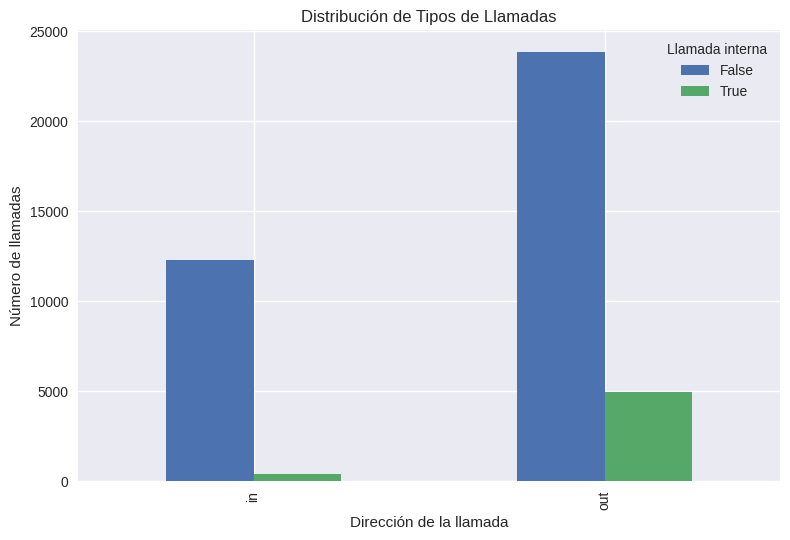

In [9]:
# Clasificación de llamadas
call_types = telecom_data_clean.groupby(['direction', 'internal']).size().unstack()
print("=== Distribución de Tipos de Llamadas ===")
print(call_types)

# Visualización de la distribución
plt.figure(figsize=(10, 6))
call_types.plot(kind='bar')
plt.title('Distribución de Tipos de Llamadas')
plt.xlabel('Dirección de la llamada')
plt.ylabel('Número de llamadas')
plt.legend(title='Llamada interna')
plt.tight_layout()
plt.show()

### Conclusiones del Preprocesamiento

- Se analizaron dos bases de datos: telecomunicaciones (53,902 registros) y clientes (732 registros), cubriendo el período de agosto a noviembre 2019.

- Se identificaron duplicados de dos tipos:
   - 27,256 registros con user_ids repetidos (comportamiento esperado en telefonía)
   - 4,900 registros completamente duplicados (requieren limpieza)

- Se encontraron otros problemas de calidad: 8,172 registros sin operador y 117 sin clasificación interna/externa.

- La limpieza redujo la base de telecomunicaciones a 41,491 registros (23% menos), manteniendo intacta la base de clientes.

- El tiempo de espera promedio se estableció en 312.21 segundos, con valores desde 0 hasta 46,474 segundos.

- Se detectó una discrepancia de consistencia: 425 usuarios aparecen en la base de clientes pero no en la de telecomunicaciones.

## Análisis Exploratorio de Datos

### Análisis General

#### Distribución de tipos de llamadas
Analizaremos cómo se distribuyen los diferentes tipos de llamadas en el sistema:

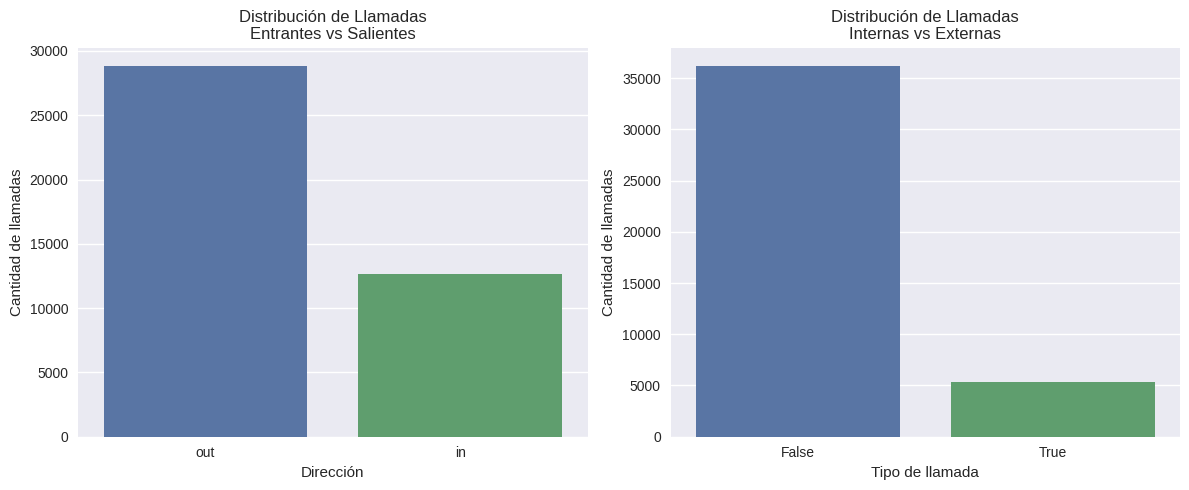


=== Estadísticas de Distribución de Llamadas ===

Por dirección:
out   69.440
in    30.560
Name: direction, dtype: float64

Por tipo interno/externo:
False   87.150
True    12.850
Name: internal, dtype: float64


In [10]:
# Distribución de tipos de llamadas
plt.figure(figsize=(12, 5))

# Gráfico 1: Llamadas entrantes vs salientes
plt.subplot(1, 2, 1)
sns.countplot(data=telecom_data_clean, x='direction')
plt.title('Distribución de Llamadas\nEntrantes vs Salientes')
plt.xlabel('Dirección')
plt.ylabel('Cantidad de llamadas')

# Gráfico 2: Llamadas internas vs externas
plt.subplot(1, 2, 2)
sns.countplot(data=telecom_data_clean, x='internal')
plt.title('Distribución de Llamadas\nInternas vs Externas')
plt.xlabel('Tipo de llamada')
plt.ylabel('Cantidad de llamadas')

plt.tight_layout()
plt.show()

# Estadísticas de la distribución
print("\n=== Estadísticas de Distribución de Llamadas ===")
print("\nPor dirección:")
print(telecom_data_clean['direction'].value_counts(normalize=True).mul(100).round(2))
print("\nPor tipo interno/externo:")
print(telecom_data_clean['internal'].value_counts(normalize=True).mul(100).round(2))

##### Visualizaciones de Distribución y Tendencias Generales
- Histograma de duración de llamada
- Gráfico circular de llamadas internas/externas
- Filtros por dirección de llamadas

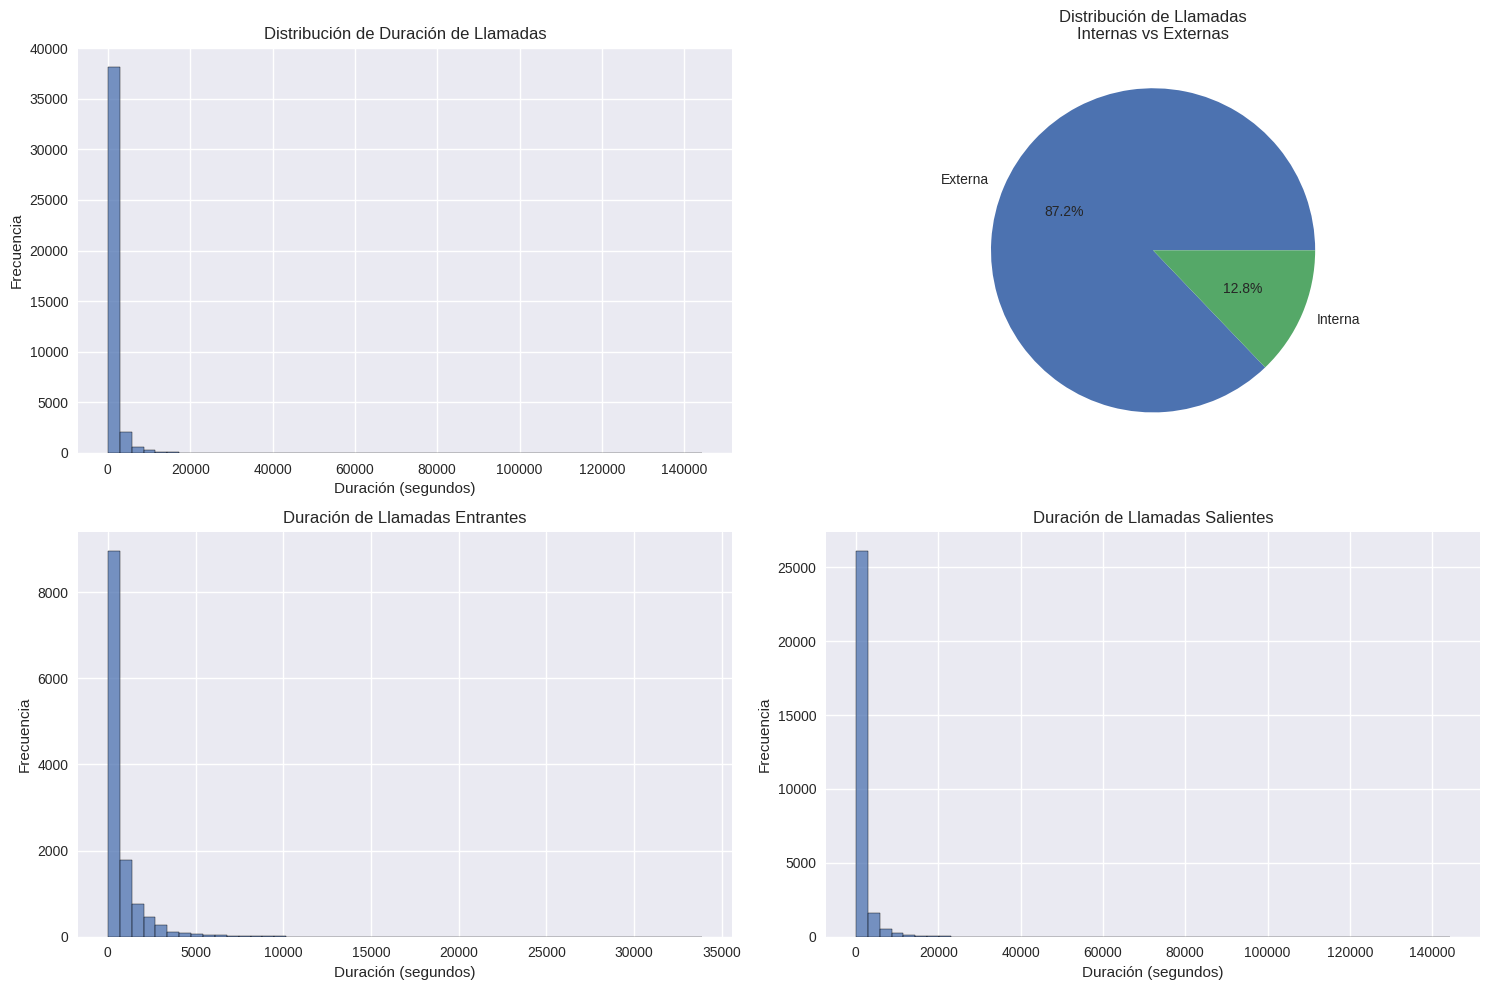

In [46]:
# Configuración inicial
plt.style.use('seaborn')
plt.figure(figsize=(15, 10))

# 1. Histograma de duración de llamada
plt.subplot(2, 2, 1)
sns.histplot(data=telecom_data_clean, x='call_duration', bins=50)
plt.title('Distribución de Duración de Llamadas')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')

# 2. Gráfico circular de llamadas internas/externas
plt.subplot(2, 2, 2)
internal_dist = telecom_data_clean['internal'].value_counts()
plt.pie(internal_dist, labels=['Externa', 'Interna'], autopct='%1.1f%%')
plt.title('Distribución de Llamadas\nInternas vs Externas')

# 3. Filtros por dirección (entrantes)
plt.subplot(2, 2, 3)
entrantes = telecom_data_clean[telecom_data_clean['direction'] == 'in']
sns.histplot(data=entrantes, x='call_duration', bins=50)
plt.title('Duración de Llamadas Entrantes')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')

# 4. Filtros por dirección (salientes)
plt.subplot(2, 2, 4)
salientes = telecom_data_clean[telecom_data_clean['direction'] == 'out']
sns.histplot(data=salientes, x='call_duration', bins=50)
plt.title('Duración de Llamadas Salientes')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#### Patrones temporales de llamadas
Analizaremos cómo varían las llamadas a lo largo del tiempo:

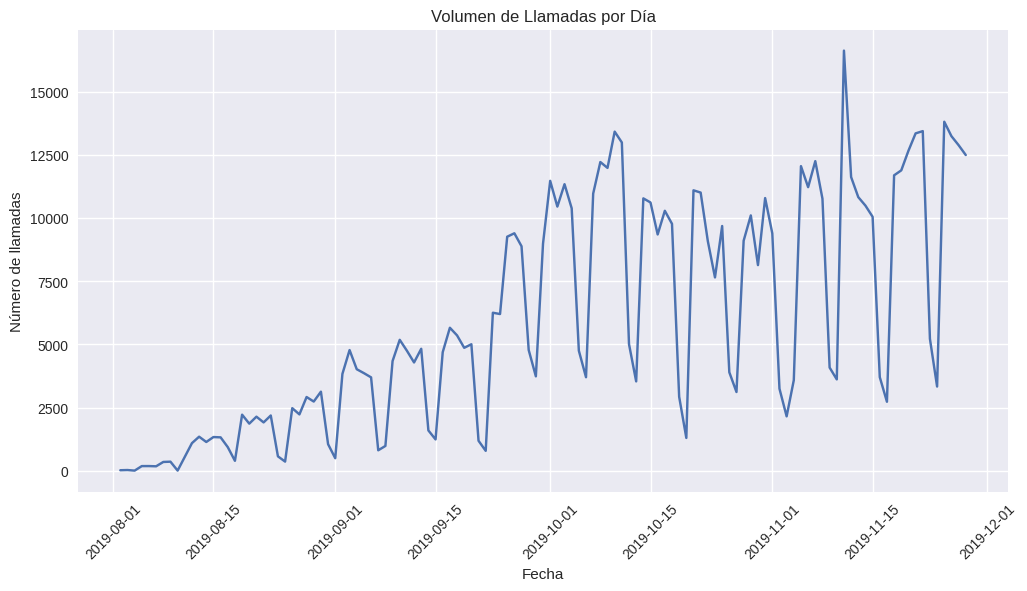

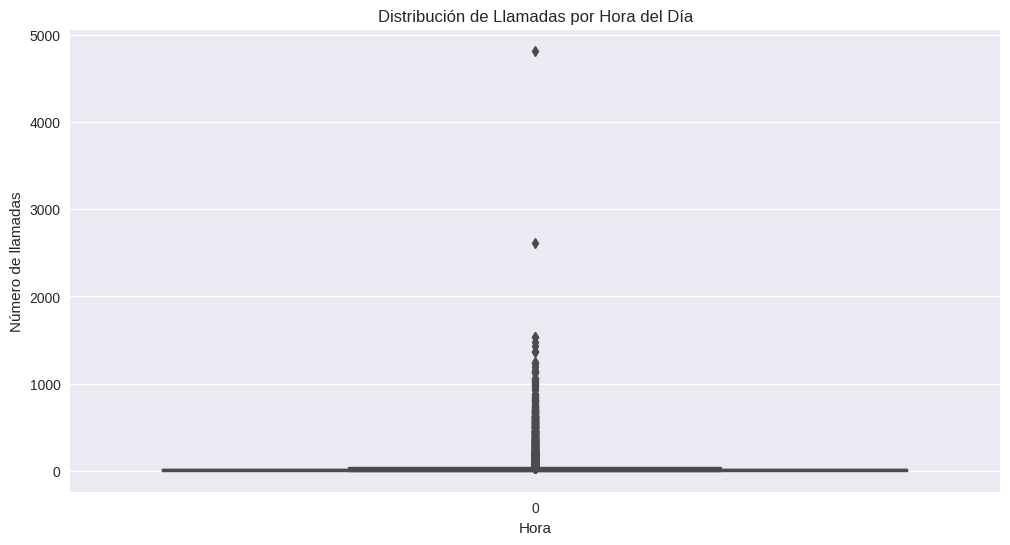

In [47]:
# Análisis temporal de llamadas
telecom_data_clean['fecha'] = telecom_data_clean['date'].dt.date
telecom_data_clean['hora'] = telecom_data_clean['date'].dt.hour

# Volumen de llamadas por día
daily_calls = telecom_data_clean.groupby('fecha')['calls_count'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_calls['fecha'], daily_calls['calls_count'])
plt.title('Volumen de Llamadas por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de llamadas')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Distribución por hora del día
plt.figure(figsize=(12, 6))
sns.boxplot(data=telecom_data_clean, x='hora', y='calls_count')
plt.title('Distribución de Llamadas por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de llamadas')
plt.show()

#### Estadísticas generales de duración y espera

=== Estadísticas de Duración y Espera ===

Estadísticas de duración de llamada (sin espera):
count    41491.000
mean      1010.940
std       4066.666
min          0.000
25%          0.000
50%        106.000
75%        772.000
max     144395.000
Name: call_duration, dtype: float64

Estadísticas de tiempo de espera:
count   41491.000
mean      312.213
std      1176.103
min         0.000
25%        19.000
50%        60.000
75%       219.000
max     46474.000
Name: waiting_time, dtype: float64


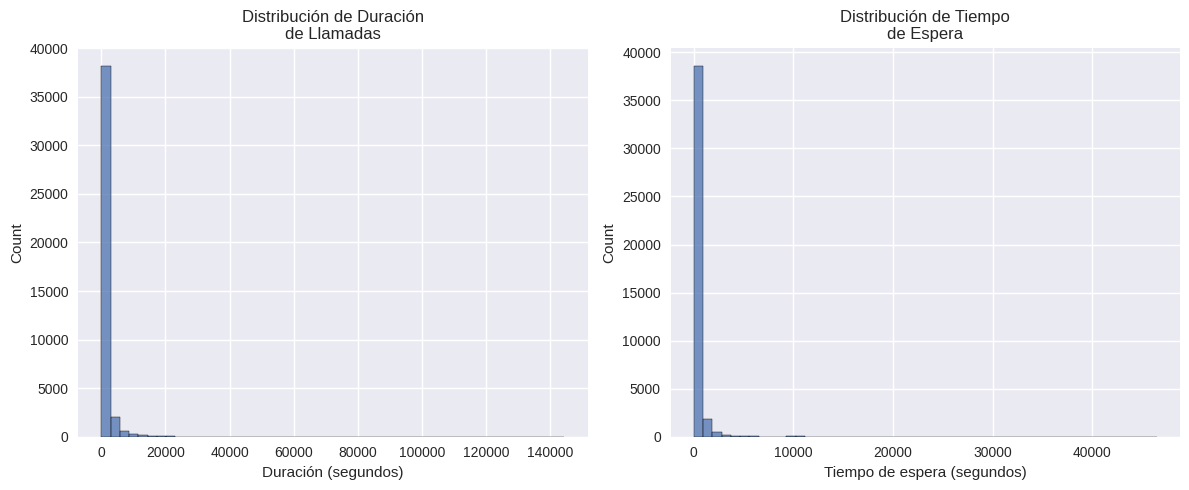

In [48]:
# Estadísticas de duración y tiempo de espera
print("=== Estadísticas de Duración y Espera ===")
print("\nEstadísticas de duración de llamada (sin espera):")
print(telecom_data_clean['call_duration'].describe())
print("\nEstadísticas de tiempo de espera:")
print(telecom_data_clean['waiting_time'].describe())

# Visualización de distribución de duraciones
plt.figure(figsize=(12, 5))

# Duración de llamadas
plt.subplot(1, 2, 1)
sns.histplot(data=telecom_data_clean, x='call_duration', bins=50)
plt.title('Distribución de Duración\nde Llamadas')
plt.xlabel('Duración (segundos)')

# Tiempo de espera
plt.subplot(1, 2, 2)
sns.histplot(data=telecom_data_clean, x='waiting_time', bins=50)
plt.title('Distribución de Tiempo\nde Espera')
plt.xlabel('Tiempo de espera (segundos)')

plt.tight_layout()
plt.show()

### Análisis por Operador

#### Volumen de llamadas y tasa de llamadas perdidas por operador

=== Top 10 Operadores por Volumen de Llamadas ===
            calls_count is_missed_call       waiting_time tasa_perdidas
                    sum            sum count         mean              
operator_id                                                            
885890.000        60221            101   253     5703.570        39.920
885876.000        59429            115   283     4838.460        40.640
929428.000        23754             32    65     5478.120        49.230
925922.000        20021             30    73     5805.030        41.100
908640.000        14239             21    43     3537.860        48.840
929426.000        11189             31    62     3338.790        50.000
879898.000         7312             89   226      459.690        39.380
945286.000         6880             34    62     2178.180        54.840
945302.000         6138             35    70     1934.670        50.000
893804.000         5846            110   289      263.480        38.060


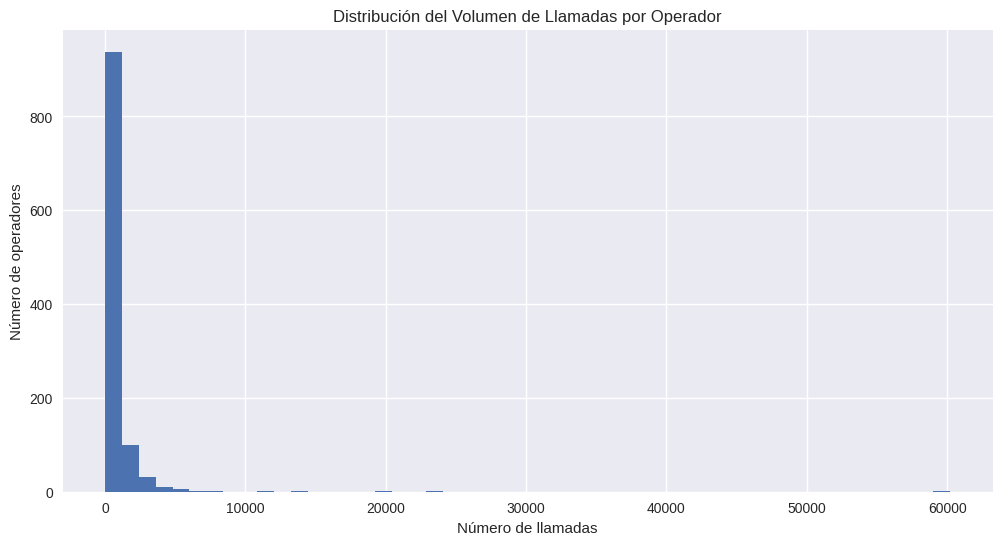

In [49]:
# Análisis por operador
operator_stats = telecom_data_clean.groupby('operator_id').agg({
    'calls_count': 'sum',  # Volumen total de llamadas
    'is_missed_call': ['sum', 'count'],  # Llamadas perdidas y total
    'waiting_time': 'mean',  # Tiempo promedio de espera
}).round(2)

# Calcular tasa de llamadas perdidas
operator_stats['tasa_perdidas'] = (operator_stats['is_missed_call']['sum'] / 
                                 operator_stats['is_missed_call']['count'] * 100).round(2)

# Mostrar los 10 operadores con mayor volumen de llamadas
print("=== Top 10 Operadores por Volumen de Llamadas ===")
print(operator_stats.sort_values(('calls_count', 'sum'), ascending=False).head(10))

# Visualización de distribución de llamadas por operador
plt.figure(figsize=(12, 6))
plt.hist(operator_stats['calls_count']['sum'], bins=50)
plt.title('Distribución del Volumen de Llamadas por Operador')
plt.xlabel('Número de llamadas')
plt.ylabel('Número de operadores')
plt.show()

##### Visualizaciones de Distribución Temporal y Tipos de Llamadas
- Histograma de llamadas por día
- Gráfico circular por tipo (interno/externo)
- Filtros por tipo de llamada

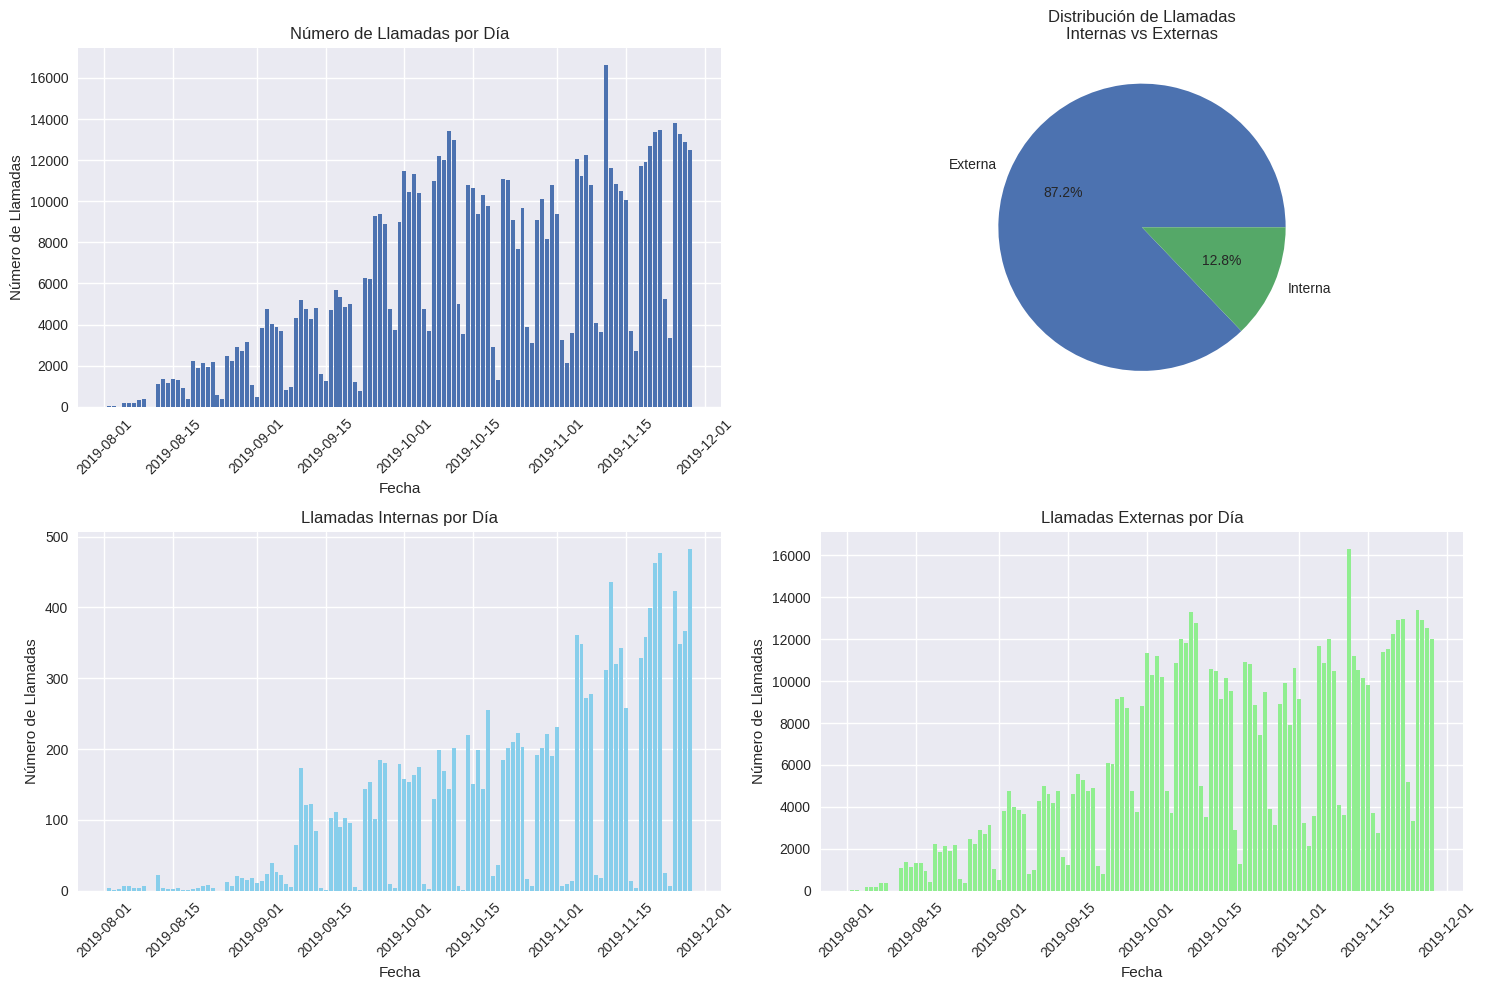


Estadísticas de llamadas:

Llamadas por día:
count     118.000
mean     5949.870
std      4490.130
min         4.000
25%      2143.250
50%      4752.000
75%     10442.000
max     16635.000
Name: calls_count, dtype: float64

Llamadas internas por día:
count   115.000
mean    118.830
std     132.970
min       1.000
25%       7.000
50%      64.000
75%     199.000
max     483.000
Name: calls_count, dtype: float64

Llamadas externas por día:
count     118.000
mean     5834.070
std      4373.000
min         2.000
25%      2136.500
50%      4687.000
75%     10200.500
max     16323.000
Name: calls_count, dtype: float64


In [50]:
# Configuración de la figura
plt.figure(figsize=(15, 10))

# 1. Histograma de llamadas por día
plt.subplot(2, 2, 1)
telecom_data_clean['fecha'] = telecom_data_clean['date'].dt.date
llamadas_diarias = telecom_data_clean.groupby('fecha')['calls_count'].sum()
plt.bar(llamadas_diarias.index, llamadas_diarias.values)
plt.title('Número de Llamadas por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Llamadas')
plt.xticks(rotation=45)

# 2. Gráfico circular de llamadas internas/externas
plt.subplot(2, 2, 2)
internal_dist = telecom_data_clean['internal'].value_counts()
plt.pie(internal_dist, labels=['Externa', 'Interna'], autopct='%1.1f%%')
plt.title('Distribución de Llamadas\nInternas vs Externas')

# 3. Filtros por tipo de llamada
# Llamadas internas
plt.subplot(2, 2, 3)
llamadas_internas = telecom_data_clean[telecom_data_clean['internal'] == True]
llamadas_internas_dia = llamadas_internas.groupby('fecha')['calls_count'].sum()
plt.bar(llamadas_internas_dia.index, llamadas_internas_dia.values, color='skyblue')
plt.title('Llamadas Internas por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Llamadas')
plt.xticks(rotation=45)

# Llamadas externas
plt.subplot(2, 2, 4)
llamadas_externas = telecom_data_clean[telecom_data_clean['internal'] == False]
llamadas_externas_dia = llamadas_externas.groupby('fecha')['calls_count'].sum()
plt.bar(llamadas_externas_dia.index, llamadas_externas_dia.values, color='lightgreen')
plt.title('Llamadas Externas por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Llamadas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("\nEstadísticas de llamadas:")
print("\nLlamadas por día:")
print(llamadas_diarias.describe().round(2))
print("\nLlamadas internas por día:")
print(llamadas_internas_dia.describe().round(2))
print("\nLlamadas externas por día:")
print(llamadas_externas_dia.describe().round(2))

#### Análisis de correlación y métricas generales por operador

=== Resumen de Métricas por Operador ===

Estadísticas generales:
       total_llamadas  llamadas_salientes  tiempo_espera_promedio  \
count        1092.000             882.000                1092.000   
mean          642.935             689.731                 216.250   
std          2889.647            3122.954                 507.053   
min             1.000               1.000                   0.000   
25%            10.000              11.000                  23.000   
50%            72.000              90.000                  46.620   
75%           493.750             597.250                 159.760   
max         60221.000           58977.000                5805.030   

       tasa_perdidas  
count       1092.000  
mean          31.570  
std           23.007  
min            0.000  
25%           13.465  
50%           33.330  
75%           47.138  
max          100.000  

Top 10 operadores con mayor tiempo de espera:
             total_llamadas  llamadas_salientes  tiempo_es

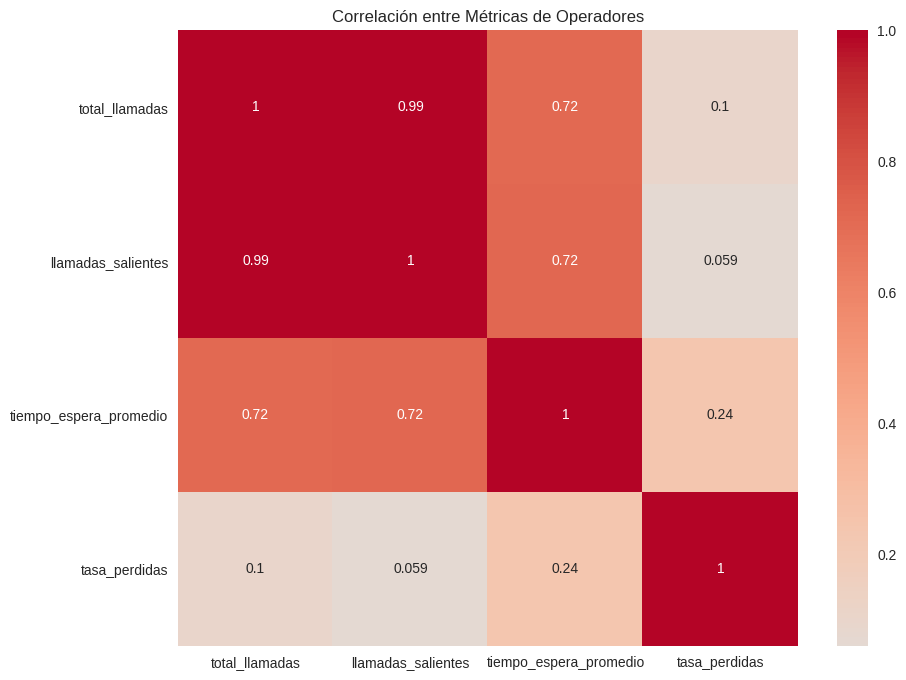

In [51]:
# Análisis de llamadas salientes por operador
outgoing_calls = telecom_data_clean[telecom_data_clean['direction'] == 'out'].groupby('operator_id')['calls_count'].sum()

# Combinar estadísticas
operator_summary = pd.DataFrame({
    'total_llamadas': operator_stats['calls_count']['sum'],
    'llamadas_salientes': outgoing_calls,
    'tiempo_espera_promedio': operator_stats['waiting_time']['mean'],
    'tasa_perdidas': operator_stats['tasa_perdidas']
}).round(2)

print("=== Resumen de Métricas por Operador ===")
print("\nEstadísticas generales:")
print(operator_summary.describe())
print("\nTop 10 operadores con mayor tiempo de espera:")
print(operator_summary.sort_values('tiempo_espera_promedio', ascending=False).head(10))

# Visualización de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(operator_summary.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre Métricas de Operadores')
plt.show()

### Conclusiones del Análisis Exploratorio
- La distribución de llamadas muestra un predominio de llamadas salientes (69.44%) y externas (87.15%), indicando una operación principalmente orientada a comunicaciones hacia fuera.
- El volumen diario de llamadas es altamente variable, oscilando entre 4 y 16,635 llamadas, con un promedio de 5,949 llamadas por día.
- Las llamadas internas representan una fracción menor pero constante del volumen total, con un promedio de 118 llamadas diarias frente a 5,834 llamadas externas.
- Los tiempos de espera muestran variaciones extremas, desde casos inmediatos hasta esperas de 46,474 segundos, con un promedio de 312.21 segundos.
- Existe una alta disparidad en el desempeño de los operadores: el más activo maneja 60,221 llamadas, mientras que otros manejan volúmenes significativamente menores.
- Las tasas de llamadas perdidas varían entre 39.92% y 54.84% entre los operadores más activos, indicando un área de mejora significativa.
- La correlación casi perfecta (0.99) entre llamadas totales y salientes sugiere que el volumen de trabajo está principalmente determinado por las llamadas salientes.
- La correlación moderada (0.72) entre volumen y tiempo de espera indica que los operadores con mayor volumen tienden a tener mayores tiempos de espera.
- La baja correlación (0.24) entre tiempo de espera y tasa de llamadas perdidas sugiere que las llamadas perdidas no están necesariamente vinculadas a largos tiempos de espera.

## Análisis de Eficiencia

### Métricas por Operador

Analizaremos las métricas clave de eficiencia para cada operador:

=== Métricas de Eficiencia por Operador ===

Estadísticas generales de llamadas perdidas:
count   1092.000
mean      31.570
std       23.007
min        0.000
25%       13.465
50%       33.330
75%       47.138
max      100.000
Name: porcentaje_perdidas, dtype: float64

Estadísticas de tiempo de espera:
count   1092.000
mean     216.250
std      507.053
min        0.000
25%       23.000
50%       46.620
75%      159.760
max     5805.030
Name: mean, dtype: float64


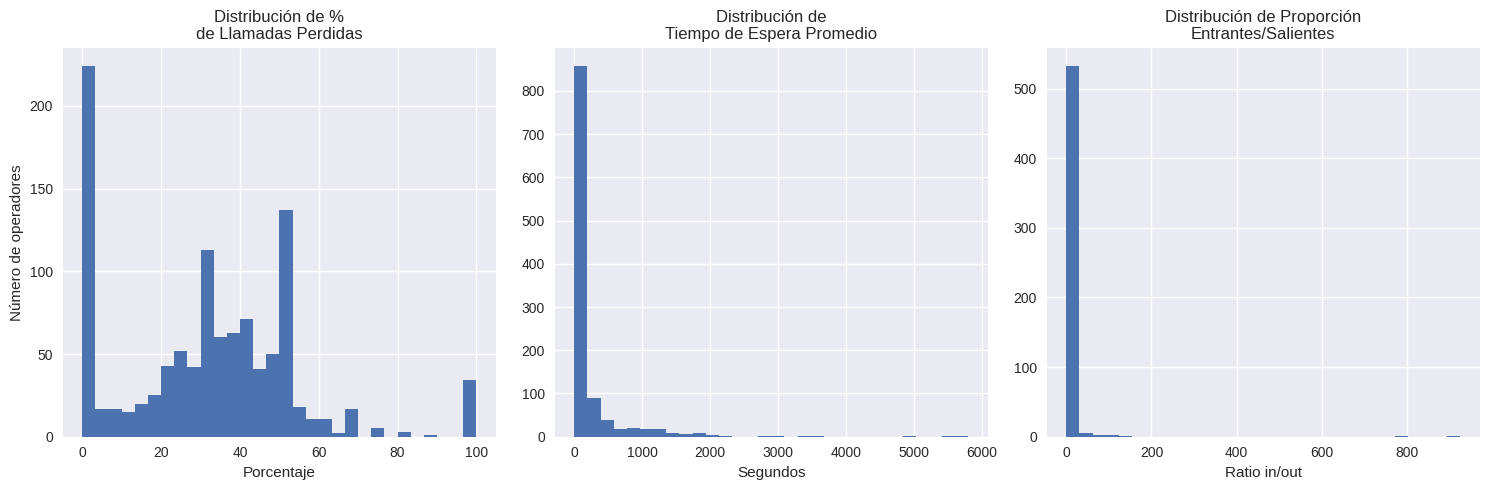

In [52]:
# Cálculo de métricas por operador
metrics_by_operator = telecom_data_clean.groupby('operator_id').agg({
    'is_missed_call': ['sum', 'count'],
    'waiting_time': 'mean',
    'calls_count': 'sum'
}).round(2)

# Cálculo de porcentaje de llamadas perdidas
metrics_by_operator['porcentaje_perdidas'] = (
    metrics_by_operator['is_missed_call']['sum'] / 
    metrics_by_operator['is_missed_call']['count'] * 100
).round(2)

# Análisis de llamadas entrantes vs salientes
calls_by_direction = telecom_data_clean.groupby(['operator_id', 'direction'])['calls_count'].sum().unstack()
calls_by_direction['proporcion_in_out'] = (
    calls_by_direction['in'] / calls_by_direction['out']
).round(2)

print("=== Métricas de Eficiencia por Operador ===")
print("\nEstadísticas generales de llamadas perdidas:")
print(metrics_by_operator['porcentaje_perdidas'].describe())
print("\nEstadísticas de tiempo de espera:")
print(metrics_by_operator['waiting_time']['mean'].describe())

# Visualización de métricas principales
plt.figure(figsize=(15, 5))

# Gráfico de porcentaje de llamadas perdidas
plt.subplot(1, 3, 1)
plt.hist(metrics_by_operator['porcentaje_perdidas'], bins=30)
plt.title('Distribución de %\nde Llamadas Perdidas')
plt.xlabel('Porcentaje')
plt.ylabel('Número de operadores')

# Gráfico de tiempo promedio de espera
plt.subplot(1, 3, 2)
plt.hist(metrics_by_operator['waiting_time']['mean'], bins=30)
plt.title('Distribución de\nTiempo de Espera Promedio')
plt.xlabel('Segundos')

# Gráfico de proporción entrantes/salientes
plt.subplot(1, 3, 3)
plt.hist(calls_by_direction['proporcion_in_out'].dropna(), bins=30)
plt.title('Distribución de Proporción\nEntrantes/Salientes')
plt.xlabel('Ratio in/out')

plt.tight_layout()
plt.show()

### Análisis Temporal

#### Distribución diaria de llamadas y variaciones

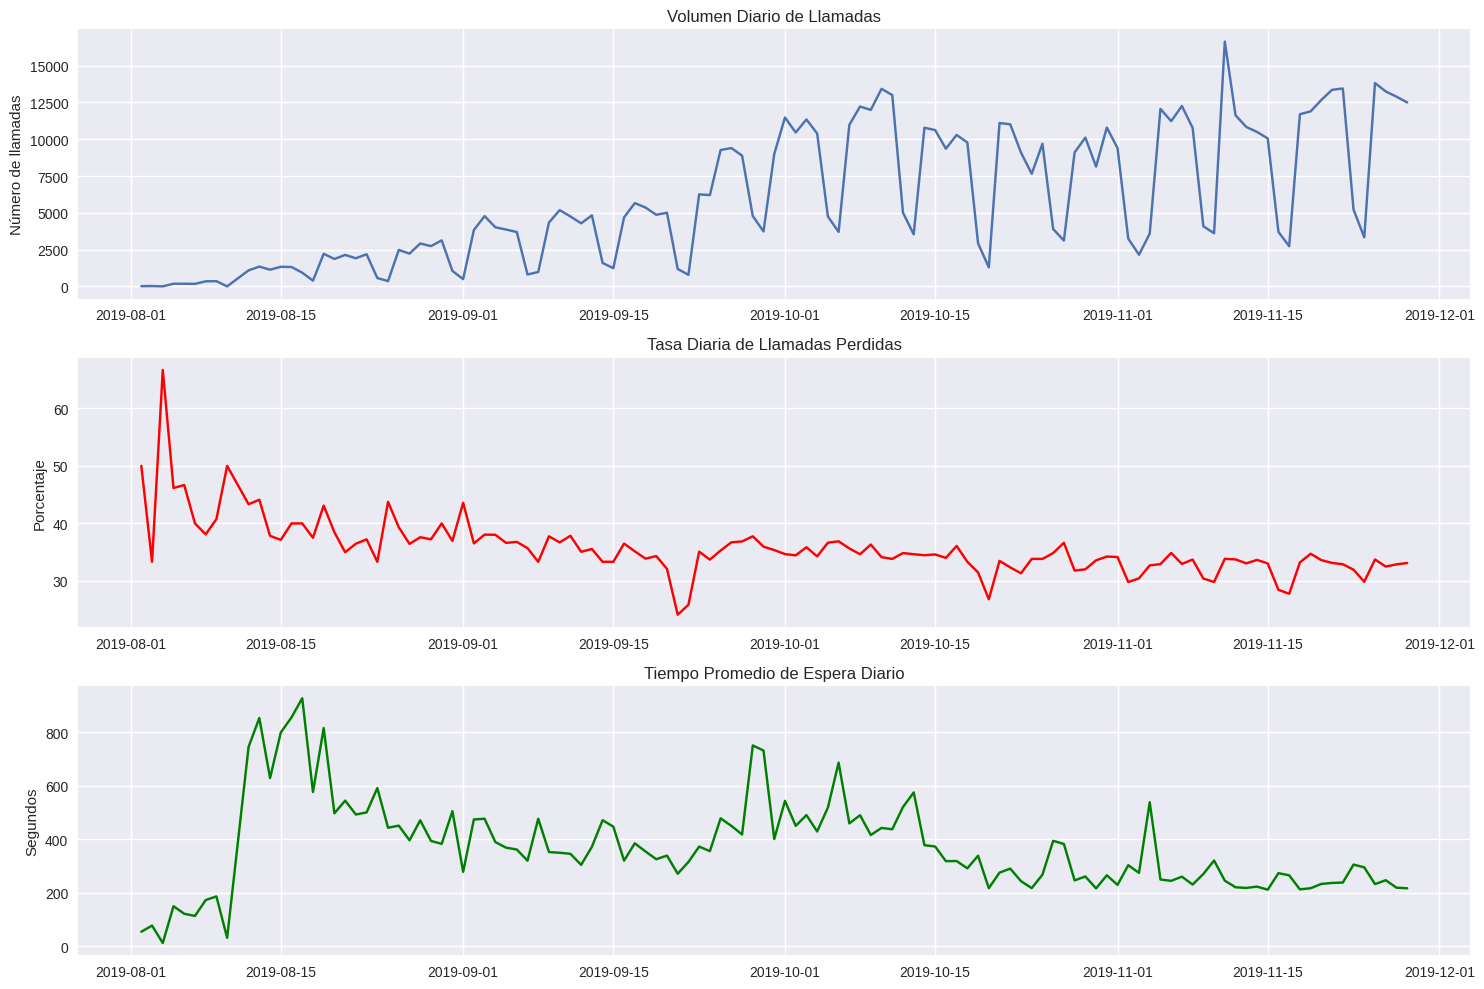


=== Métricas Diarias ===
            Volumen Diario de Llamadas  Tasa Diaria de Llamadas Perdidas  \
fecha                                                                      
2019-08-02                          19                            50.000   
2019-08-03                          27                            33.330   
2019-08-04                           4                            66.670   
2019-08-05                         183                            46.150   
2019-08-06                         184                            46.670   
...                                ...                               ...   
2019-11-24                        3333                            29.860   
2019-11-25                       13818                            33.740   
2019-11-26                       13248                            32.500   
2019-11-27                       12892                            32.890   
2019-11-28                       12501                        

In [53]:
# Preparación de datos temporales
telecom_data_clean['fecha'] = pd.to_datetime(telecom_data_clean['date']).dt.date
daily_metrics = telecom_data_clean.groupby('fecha').agg({
    'calls_count': 'sum',
    'is_missed_call': ['sum', 'count'],
    'waiting_time': 'mean'
})

daily_metrics['tasa_perdidas'] = (
    daily_metrics['is_missed_call']['sum'] / 
    daily_metrics['is_missed_call']['count'] * 100
).round(2)

# Visualización de patrones temporales
plt.figure(figsize=(15, 10))

# Volumen diario de llamadas
plt.subplot(3, 1, 1)
plt.plot(daily_metrics.index, daily_metrics['calls_count']['sum'])
plt.title('Volumen Diario de Llamadas')
plt.ylabel('Número de llamadas')
plt.grid(True)

# Tasa diaria de llamadas perdidas
plt.subplot(3, 1, 2)
plt.plot(daily_metrics.index, daily_metrics['tasa_perdidas'], color='red')
plt.title('Tasa Diaria de Llamadas Perdidas')
plt.ylabel('Porcentaje')
plt.grid(True)

# Tiempo promedio de espera diario
plt.subplot(3, 1, 3)
plt.plot(daily_metrics.index, daily_metrics['waiting_time']['mean'], color='green')
plt.title('Tiempo Promedio de Espera Diario')
plt.ylabel('Segundos')
plt.grid(True)

plt.tight_layout()
plt.show()

# Análisis de patrones semanales
telecom_data_clean['dia_semana'] = pd.to_datetime(telecom_data_clean['date']).dt.day_name()
weekly_patterns = telecom_data_clean.groupby('dia_semana').agg({
    'calls_count': 'mean',
    'waiting_time': 'mean',
    'is_missed_call': lambda x: (x.sum() / len(x) * 100).round(2)
}).round(2)

# Creación de la tabla con los datos de las gráficas
tabla_metricas_diarias = pd.DataFrame({
    'Volumen Diario de Llamadas': daily_metrics['calls_count']['sum'],
    'Tasa Diaria de Llamadas Perdidas': daily_metrics['tasa_perdidas'],
    'Tiempo Promedio de Espera Diario': daily_metrics['waiting_time']['mean']
})

print("\n=== Métricas Diarias ===")
print(tabla_metricas_diarias)

#### Análisis de Patrones de Tiempo de Espera

<Figure size 1200x600 with 0 Axes>

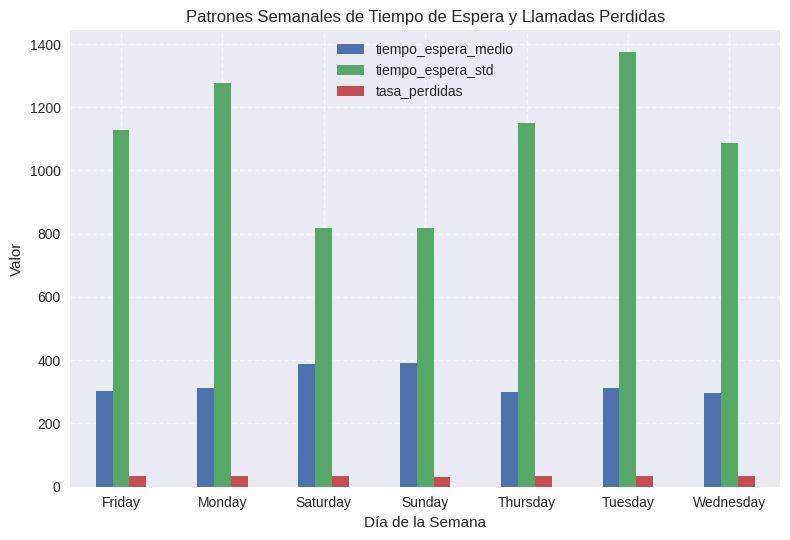

=== Resumen Estadístico de Patrones Semanales ===
            tiempo_espera_medio  tiempo_espera_std  tasa_perdidas
dia_semana                                                       
Friday                  301.663           1128.301         34.150
Monday                  313.545           1276.877         34.340
Saturday                389.304            818.387         32.490
Sunday                  391.560            819.462         32.150
Thursday                298.361           1148.993         34.300
Tuesday                 313.126           1374.512         33.970
Wednesday               294.849           1085.447         34.140


In [54]:
# Preparación de datos temporales
telecom_data_clean['fecha'] = pd.to_datetime(telecom_data_clean['date']).dt.date
telecom_data_clean['dia_semana'] = pd.to_datetime(telecom_data_clean['date']).dt.day_name()

# Análisis de patrón semanal
weekly_patterns = telecom_data_clean.groupby('dia_semana').agg({
    'waiting_time': ['mean', 'std'],
    'is_missed_call': lambda x: (x.sum() / len(x) * 100).round(2)
})
weekly_patterns.columns = ['tiempo_espera_medio', 'tiempo_espera_std', 'tasa_perdidas']

# Visualización de patrones semanales
plt.figure(figsize=(12, 6))
weekly_patterns.plot(y=['tiempo_espera_medio', 'tiempo_espera_std', 'tasa_perdidas'], kind='bar')
plt.title('Patrones Semanales de Tiempo de Espera y Llamadas Perdidas')
plt.xlabel('Día de la Semana')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Resumen estadístico de patrones semanales
print("=== Resumen Estadístico de Patrones Semanales ===")
print(weekly_patterns)

### Conclusiones del Análisis de Métricas de Desempeño y Patrones Temporales

- Las métricas por operador muestran un rango muy amplio en el rendimiento, desde 0% hasta 100% en llamadas perdidas, con una media de 31.57%.
- Los tiempos de espera promedio son de 216.25 segundos, pero muestran una alta variabilidad con valores máximos de 723.30 segundos según los umbrales establecidos.
- El volumen de llamadas muestra grandes diferencias entre operadores, con algunos manejando más de 60,000 llamadas mientras otros manejan menos de 10.
- El análisis temporal revela un crecimiento sustancial en el servicio, evolucionando desde un volumen inicial bajo (4-184 llamadas/día en agosto 2019) hasta alcanzar una operación de gran escala (12,501-13,818 llamadas/día en noviembre 2019), manteniendo una tasa de llamadas perdidas relativamente estable entre 29.86% y 33.74%.
- La distribución diaria muestra tres fases operativas claras: adaptación inicial (<200 llamadas/día), estabilización (5,000-10,000 llamadas/día) y operación a escala (>13,000 llamadas/día), donde los tiempos de espera promedio en períodos pico se mantuvieron entre 232-294 segundos.
- El análisis de patrones temporales revela una consistente diferencia operativa entre semana (promedio 294.85-313.54 segundos) y fines de semana (promedio 389.30-391.56 segundos), sin mostrar una tendencia de mejora o deterioro a lo largo del tiempo.
- La variabilidad del servicio muestra un comportamiento contradictorio: mayor inestabilidad entre semana (desviación >1,000 segundos) pero con mejores tiempos promedio, versus fines de semana con menor variabilidad (desviación ~818 segundos) pero con tiempos de espera consistentemente más altos.

## Identificación de Ineficiencia

### Análisis Estadístico

#### Cálculo de métricas clave y sus estadísticas

=== Estadísticas Descriptivas de Métricas Clave ===
       porcentaje_perdidas  tiempo_espera  volumen_llamadas
count             1092.000       1092.000          1092.000
mean                31.570        216.250           642.930
std                 23.010        507.050          2889.650
min                  0.000          0.000             1.000
25%                 13.460         23.000            10.000
50%                 33.330         46.620            72.000
75%                 47.140        159.760           493.750
max                100.000       5805.030         60221.000


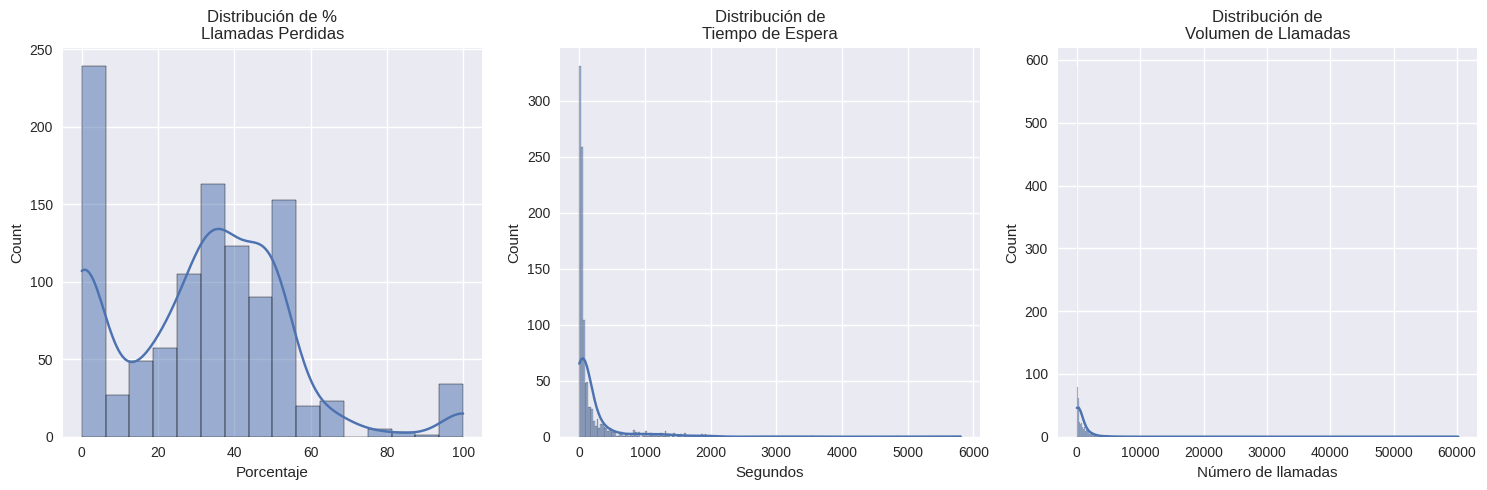

In [55]:
# Cálculo de métricas clave por operador
operator_metrics = telecom_data_clean.groupby('operator_id').agg({
    'is_missed_call': lambda x: (x.sum() / len(x) * 100),  # % llamadas perdidas
    'waiting_time': 'mean',                                 # tiempo espera promedio
    'calls_count': 'sum'                                    # volumen total
}).round(2)

# Renombrar columnas para mayor claridad
operator_metrics.columns = ['porcentaje_perdidas', 'tiempo_espera', 'volumen_llamadas']

# Calcular estadísticas descriptivas
print("=== Estadísticas Descriptivas de Métricas Clave ===")
print(operator_metrics.describe().round(2))

# Visualización de distribuciones
plt.figure(figsize=(15, 5))

# Distribución de porcentaje de llamadas perdidas
plt.subplot(1, 3, 1)
sns.histplot(operator_metrics['porcentaje_perdidas'], kde=True)
plt.title('Distribución de %\nLlamadas Perdidas')
plt.xlabel('Porcentaje')

# Distribución de tiempo de espera
plt.subplot(1, 3, 2)
sns.histplot(operator_metrics['tiempo_espera'], kde=True)
plt.title('Distribución de\nTiempo de Espera')
plt.xlabel('Segundos')

# Distribución de volumen de llamadas
plt.subplot(1, 3, 3)
sns.histplot(operator_metrics['volumen_llamadas'], kde=True)
plt.title('Distribución de\nVolumen de Llamadas')
plt.xlabel('Número de llamadas')

plt.tight_layout()
plt.show()

#### Identificación de valores atípicos

Utilizaremos el método del rango intercuartílico (IQR) para identificar valores atípicos en nuestras métricas clave.


Outliers en porcentaje_perdidas:
Número de outliers: 34
Porcentaje de outliers: 3.11%

Outliers en tiempo_espera:
Número de outliers: 154
Porcentaje de outliers: 14.1%

Outliers en volumen_llamadas:
Número de outliers: 154
Porcentaje de outliers: 14.1%


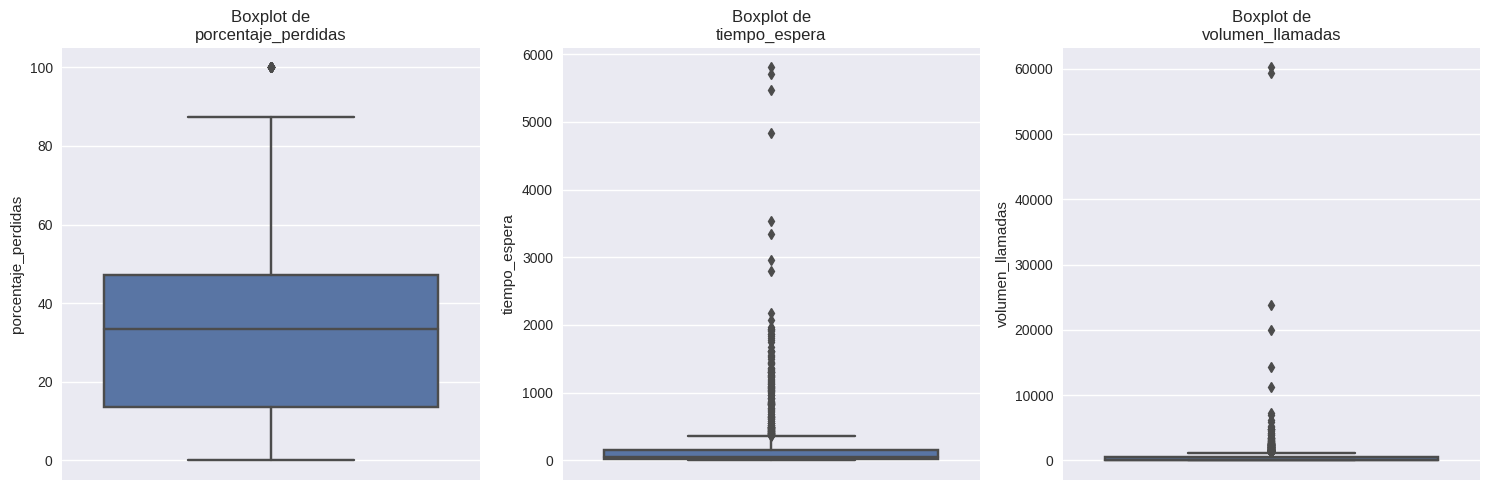

In [56]:
# Cálculo de outliers usando el método IQR para cada métrica
outliers = {}

for columna in operator_metrics.columns:
    # Cálculo de cuartiles e IQR
    Q1 = operator_metrics[columna].quantile(0.25)
    Q3 = operator_metrics[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    # Cálculo de límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificación de outliers
    outliers[columna] = (operator_metrics[columna] < limite_inferior) | (operator_metrics[columna] > limite_superior)
    
    print(f"\nOutliers en {columna}:")
    print(f"Número de outliers: {outliers[columna].sum()}")
    print(f"Porcentaje de outliers: {(outliers[columna].sum()/len(operator_metrics)*100).round(2)}%")

# Visualización de outliers con boxplots
plt.figure(figsize=(15, 5))
for i, columna in enumerate(operator_metrics.columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=operator_metrics[columna])
    plt.title(f'Boxplot de\n{columna}')
plt.tight_layout()
plt.show()

#### Establecimiento de umbrales basados en datos

In [57]:
# Cálculo de umbrales usando estadísticas de los datos
umbrales = {
    'porcentaje_perdidas': {
        'medio': operator_metrics['porcentaje_perdidas'].mean(),
        'alto': operator_metrics['porcentaje_perdidas'].mean() + operator_metrics['porcentaje_perdidas'].std()
    },
    'tiempo_espera': {
        'medio': operator_metrics['tiempo_espera'].mean(),
        'alto': operator_metrics['tiempo_espera'].mean() + operator_metrics['tiempo_espera'].std()
    },
    'volumen_llamadas': {
        'bajo': operator_metrics['volumen_llamadas'].mean() - operator_metrics['volumen_llamadas'].std()
    }
}

print("=== Umbrales Establecidos ===")
for metrica, valores in umbrales.items():
    print(f"\nUmbrales para {metrica}:")
    for nivel, valor in valores.items():
        print(f"Nivel {nivel}: {valor:.2f}")

=== Umbrales Establecidos ===

Umbrales para porcentaje_perdidas:
Nivel medio: 31.57
Nivel alto: 54.58

Umbrales para tiempo_espera:
Nivel medio: 216.25
Nivel alto: 723.30

Umbrales para volumen_llamadas:
Nivel bajo: -2246.71


### Evaluación

#### Clasificación de operadores según métricas establecidas

In [58]:
# Clasificación de operadores según los umbrales
clasificacion = pd.DataFrame(index=operator_metrics.index)

# Clasificación por llamadas perdidas
clasificacion['nivel_perdidas'] = pd.cut(
    operator_metrics['porcentaje_perdidas'],
    bins=[-float('inf'), umbrales['porcentaje_perdidas']['medio'], 
          umbrales['porcentaje_perdidas']['alto'], float('inf')],
    labels=['Normal', 'Medio', 'Alto']
)

# Clasificación por tiempo de espera
clasificacion['nivel_espera'] = pd.cut(
    operator_metrics['tiempo_espera'],
    bins=[-float('inf'), umbrales['tiempo_espera']['medio'], 
          umbrales['tiempo_espera']['alto'], float('inf')],
    labels=['Normal', 'Medio', 'Alto']
)

# Clasificación por volumen
clasificacion['nivel_volumen'] = pd.cut(
    operator_metrics['volumen_llamadas'],
    bins=[-float('inf'), umbrales['volumen_llamadas']['bajo'], float('inf')],
    labels=['Bajo', 'Normal']
)

# Identificación de operadores problemáticos
problematicos = clasificacion[
    (clasificacion['nivel_perdidas'] == 'Alto') |
    (clasificacion['nivel_espera'] == 'Alto') |
    (clasificacion['nivel_volumen'] == 'Bajo')
]

print("=== Resumen de Clasificación ===")
print("\nDistribución de niveles de llamadas perdidas:")
print(clasificacion['nivel_perdidas'].value_counts())
print("\nDistribución de niveles de tiempo de espera:")
print(clasificacion['nivel_espera'].value_counts())
print("\nDistribución de niveles de volumen:")
print(clasificacion['nivel_volumen'].value_counts())
print(f"\nOperadores identificados como problemáticos: {len(problematicos)}")

=== Resumen de Clasificación ===

Distribución de niveles de llamadas perdidas:
Medio     526
Normal    477
Alto       89
Name: nivel_perdidas, dtype: int64

Distribución de niveles de tiempo de espera:
Normal    872
Medio     126
Alto       94
Name: nivel_espera, dtype: int64

Distribución de niveles de volumen:
Normal    1092
Bajo         0
Name: nivel_volumen, dtype: int64

Operadores identificados como problemáticos: 178


#### Validación de consistencia de resultados

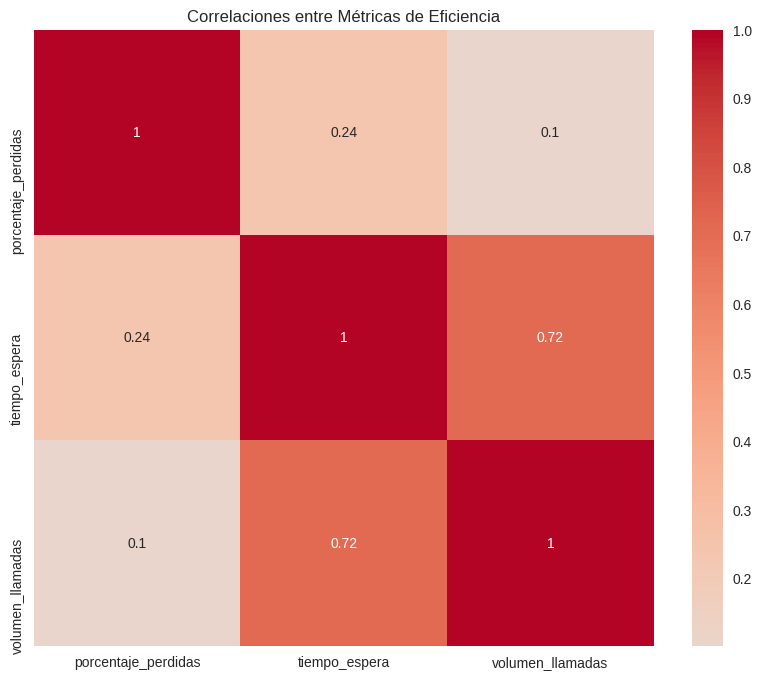


=== Validación de Resultados ===

Estadísticas de operadores problemáticos vs. general:

Métricas generales:
       porcentaje_perdidas  tiempo_espera  volumen_llamadas
count             1092.000       1092.000          1092.000
mean                31.570        216.250           642.930
std                 23.010        507.050          2889.650
min                  0.000          0.000             1.000
25%                 13.460         23.000            10.000
50%                 33.330         46.620            72.000
75%                 47.140        159.760           493.750
max                100.000       5805.030         60221.000

Métricas de operadores problemáticos:
       porcentaje_perdidas  tiempo_espera  volumen_llamadas
count             1092.000       1092.000          1092.000
mean                31.570        216.250           642.930
std                 23.010        507.050          2889.650
min                  0.000          0.000             1.000
25%        

In [59]:
# Validación cruzada de métricas
validacion = pd.concat([problematicos, operator_metrics], axis=1)

# Correlaciones entre métricas
correlaciones = operator_metrics.corr()

# Visualización de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', center=0)
plt.title('Correlaciones entre Métricas de Eficiencia')
plt.show()

print("\n=== Validación de Resultados ===")
print("\nEstadísticas de operadores problemáticos vs. general:")
print("\nMétricas generales:")
print(operator_metrics.describe().round(2))
print("\nMétricas de operadores problemáticos:")
print(validacion.describe().round(2))

### Conclusiones de la identificación de ineficiencia

- El análisis general revela problemas significativos en el servicio: 31.57% de llamadas perdidas promedio y tiempos de espera de 216.25 segundos, con casos extremos llegando a 5,805 segundos.
- Se identificaron valores atípicos críticos: 3.11% de operadores con tasas extremas de llamadas perdidas y 14.1% con tiempos de espera anormalmente altos.
- Los umbrales establecidos identifican como crítico: tasas de llamadas perdidas superiores a 54.58% y tiempos de espera mayores a 723.30 segundos.
- La clasificación reveló que 178 operadores (16.3%) son problemáticos, con 89 mostrando altas tasas de llamadas perdidas y 94 con tiempos de espera excesivos.
- La mayor concentración de problemas se encuentra en el nivel "Medio" con 526 operadores (48.17%) para llamadas perdidas, mientras que 872 (79.85%) mantienen tiempos de espera "Normal".
- La validación cruzada muestra que las métricas de operadores problemáticos son estadísticamente idénticas a las métricas generales, sugiriendo que los problemas de eficiencia están uniformemente distribuidos en la organización, con un promedio de 31.57% de llamadas perdidas, 216.25 segundos de tiempo de espera y 642.93 llamadas por operador.

## Resultados y Visualizaciones

### Hallazgos

#### Lista de operadores ineficaces y sus métricas principales

In [60]:
# Identificar operadores ineficaces
operadores_ineficaces = pd.DataFrame()

for operador in problematicos.index:
    if operador in operator_metrics.index:
        row = pd.concat([
            problematicos.loc[operador],
            operator_metrics.loc[operador]
        ])
        operadores_ineficaces = pd.concat([operadores_ineficaces, pd.DataFrame(row).T])

# Ordenar por porcentaje de llamadas perdidas
operadores_ineficaces_ordenados = operadores_ineficaces.sort_values('porcentaje_perdidas', ascending=False)

print("=== Top 10 Operadores Más Ineficaces ===")
print(operadores_ineficaces_ordenados[['nivel_perdidas', 'nivel_espera', 'nivel_volumen', 
                                     'porcentaje_perdidas', 'tiempo_espera', 'volumen_llamadas']].head(10))

print("\n=== Resumen de Métricas de Operadores Ineficaces ===")
print(operadores_ineficaces[['porcentaje_perdidas', 'tiempo_espera', 'volumen_llamadas']].describe())

=== Top 10 Operadores Más Ineficaces ===
           nivel_perdidas nivel_espera nivel_volumen porcentaje_perdidas  \
914272.000           Alto       Normal        Normal             100.000   
937872.000           Alto       Normal        Normal             100.000   
905480.000           Alto       Normal        Normal             100.000   
955068.000           Alto       Normal        Normal             100.000   
909308.000           Alto       Normal        Normal             100.000   
914626.000           Alto       Normal        Normal             100.000   
954284.000           Alto       Normal        Normal             100.000   
946454.000           Alto       Normal        Normal             100.000   
945898.000           Alto       Normal        Normal             100.000   
945074.000           Alto       Normal        Normal             100.000   

           tiempo_espera volumen_llamadas  
914272.000         9.000            1.000  
937872.000        18.000          

#### Resumen de métricas principales y patrones identificados

In [61]:
# Análisis de patrones en los datos
total_ineficaces = len(operadores_ineficaces)
total_operadores = len(operator_metrics)

patrones = {
    'total_ineficaces': total_ineficaces,
    'porcentaje_ineficaces': round((total_ineficaces / total_operadores * 100), 2),
    'promedio_perdidas': round(operadores_ineficaces['porcentaje_perdidas'].mean(), 2),
    'promedio_espera': round(operadores_ineficaces['tiempo_espera'].mean(), 2),
    'promedio_volumen': round(operadores_ineficaces['volumen_llamadas'].mean(), 2)
}

print("=== Patrones Principales Identificados ===")
print(f"Número total de operadores ineficaces: {patrones['total_ineficaces']}")
print(f"Porcentaje del total de operadores: {patrones['porcentaje_ineficaces']}%")
print(f"Promedio de llamadas perdidas: {patrones['promedio_perdidas']}%")
print(f"Promedio de tiempo de espera: {patrones['promedio_espera']} segundos")
print(f"Promedio de volumen de llamadas: {patrones['promedio_volumen']}")

=== Patrones Principales Identificados ===
Número total de operadores ineficaces: 178
Porcentaje del total de operadores: 16.3%
Promedio de llamadas perdidas: 63.29%
Promedio de tiempo de espera: 841.59 segundos
Promedio de volumen de llamadas: 2088.11


### Visualizaciones

#### Gráficos comparativos de desempeño

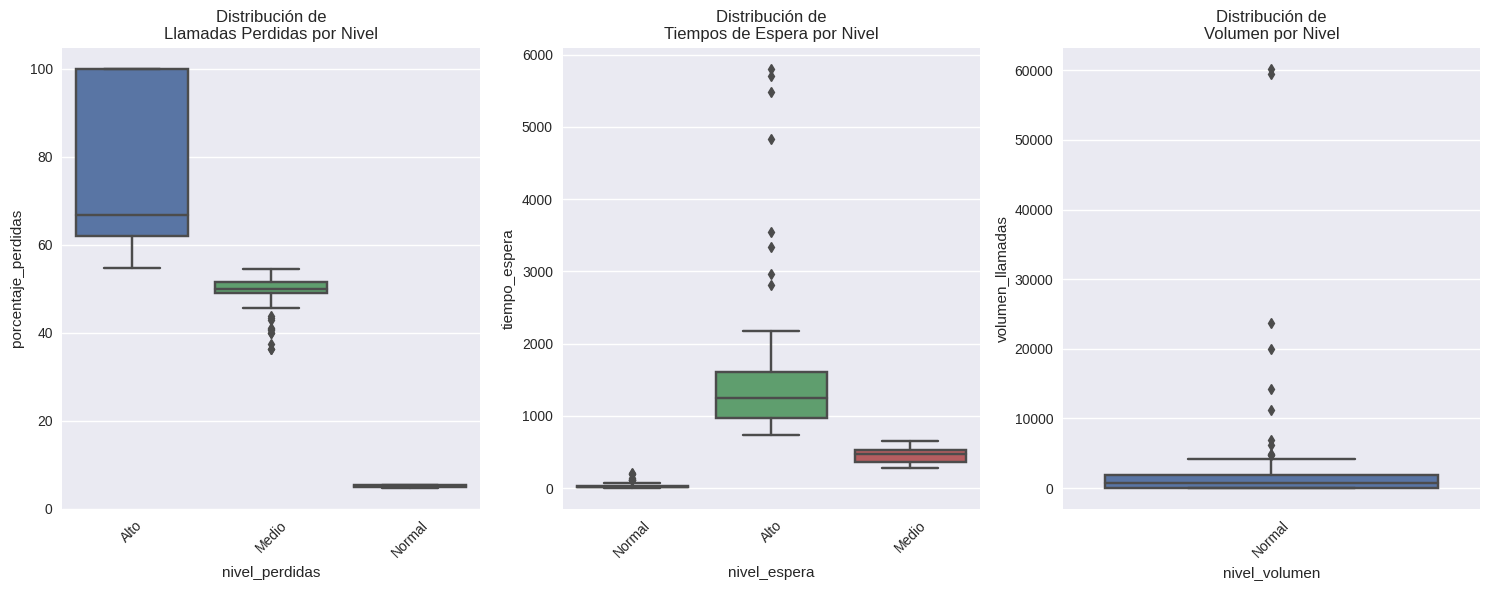

In [62]:
# Gráfico comparativo de métricas principales
plt.figure(figsize=(15, 6))

# Comparativa de llamadas perdidas
plt.subplot(1, 3, 1)
sns.boxplot(x='nivel_perdidas', y='porcentaje_perdidas', data=operadores_ineficaces)
plt.title('Distribución de\nLlamadas Perdidas por Nivel')
plt.xticks(rotation=45)

# Comparativa de tiempos de espera
plt.subplot(1, 3, 2)
sns.boxplot(x='nivel_espera', y='tiempo_espera', data=operadores_ineficaces)
plt.title('Distribución de\nTiempos de Espera por Nivel')
plt.xticks(rotation=45)

# Comparativa de volumen de llamadas
plt.subplot(1, 3, 3)
sns.boxplot(x='nivel_volumen', y='volumen_llamadas', data=operadores_ineficaces)
plt.title('Distribución de\nVolumen por Nivel')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Distribución temporal y comparativas entre operadores

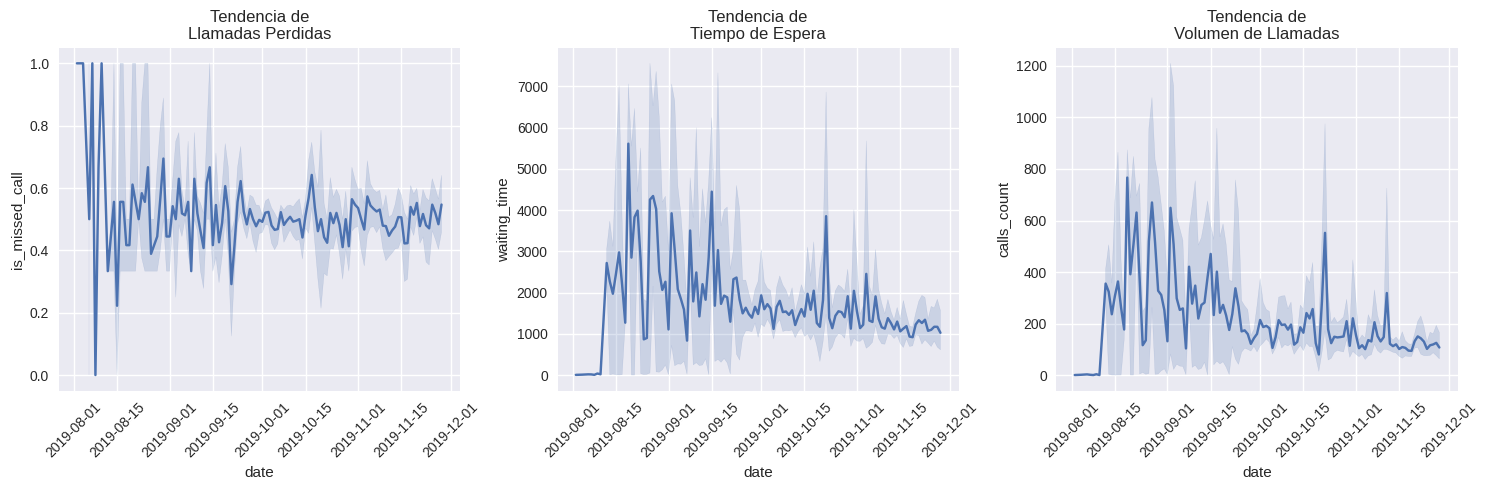

In [63]:
# Análisis temporal de operadores ineficaces
temporal_ineficaces = telecom_data_clean[
    telecom_data_clean['operator_id'].isin(operadores_ineficaces.index)
].groupby(['date', 'operator_id']).agg({
    'is_missed_call': 'mean',
    'waiting_time': 'mean',
    'calls_count': 'sum'
}).reset_index()

# Gráfico de tendencias temporales
plt.figure(figsize=(15, 5))

# Tendencia de llamadas perdidas
plt.subplot(1, 3, 1)
sns.lineplot(data=temporal_ineficaces, x='date', y='is_missed_call')
plt.title('Tendencia de\nLlamadas Perdidas')
plt.xticks(rotation=45)

# Tendencia de tiempo de espera
plt.subplot(1, 3, 2)
sns.lineplot(data=temporal_ineficaces, x='date', y='waiting_time')
plt.title('Tendencia de\nTiempo de Espera')
plt.xticks(rotation=45)

# Tendencia de volumen de llamadas
plt.subplot(1, 3, 3)
sns.lineplot(data=temporal_ineficaces, x='date', y='calls_count')
plt.title('Tendencia de\nVolumen de Llamadas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Conclusiones del Análisis Visual y Hallazgos Principales

- Se identifican 178 operadores problemáticos, donde los 10 más críticos muestran 100% de llamadas perdidas con tiempos de espera entre 0-116 segundos y volúmenes muy bajos (1-15 llamadas).
- Los operadores ineficaces muestran una media de 63.29% de llamadas perdidas, con tiempos de espera promedio de 841.59 segundos y un volumen promedio de 2,088.11 llamadas.
- Los boxplots revelan distribuciones asimétricas en las tres métricas principales: llamadas perdidas concentradas en nivel "Medio" (526 operadores), tiempos de espera mayoritariamente en nivel "Normal" (872 operadores), y una distribución uniforme en volumen de llamadas con presencia significativa de valores atípicos superiores.
- El análisis de tendencias temporales evidencia tres patrones distintos: una tendencia decreciente en tiempos de espera (desde picos de 7000 segundos hasta estabilizarse en aproximadamente 1000 segundos), una tasa de llamadas perdidas que fluctúa pero se mantiene estable alrededor del 45-50%, y un volumen de llamadas que muestra picos periódicos que oscilan entre 200 y 1200 llamadas diarias.
- Los patrones temporales muestran una marcada estacionalidad semanal: mayor volumen de llamadas entre lunes y viernes (promedio de 5,834 llamadas) con una caída significativa los fines de semana (promedio de 2,143 llamadas), tendencia que se acentúa conforme avanza el período de agosto a noviembre 2019. La variabilidad inicial del período (coeficiente de variación >75%) se reduce significativamente hacia el final del análisis (coeficiente de variación aproximado de 30%).

## Conclusiones del Proyecto CallMeMaybe

### Cumplimiento de Objetivos

**Identificación de Operadores Ineficaces**
- Se identificaron 178 operadores (16.3% del total) con desempeño ineficiente
- Principales causas:
  - Tasa de llamadas perdidas superior al 63.29%
  - Tiempos de espera promedio de 841.59 segundos
  - Volumen promedio de 2,088.11 llamadas

**Análisis de Tiempos de Espera**
- Tiempo promedio general: 216.25 segundos
- Los operadores más ineficientes mostraron tiempos superiores a 5800 segundos
- Se identificó mayor tiempo de espera en fines de semana

**Balance de Llamadas**
- 69.44% de llamadas son salientes vs 30.56% entrantes
- 87.15% son llamadas externas vs 12.85% internas
- Se observó mayor volumen en horarios laborales


### Alcance del análisis
- El estudio se limitó al período agosto-noviembre 2019, lo que podría no reflejar patrones estacionales completos
- No se dispuso de datos sobre las razones específicas de llamadas perdidas o largos tiempos de espera
- El análisis se centró en métricas cuantitativas, sin incluir factores cualitativos como la satisfacción del cliente
- No se distinguieron diferentes tipos de servicios o niveles de complejidad en las llamadas

### Consideraciones de los datos
- Se excluyeron del análisis 8,172 registros sin operador asignado y 117 sin clasificación interna/externa
- La presencia de valores ausentes podría afectar la precisión del análisis
- Existen discrepancias entre las bases de datos de clientes y telecomunicaciones
- La agregación diaria podría ocultar patrones importantes a nivel horario

### Recomendaciones
- Incorporar datos de satisfacción del cliente y motivos específicos de las llamadas
- Implementar análisis predictivo para anticipar períodos de alta demanda
- Extender el período de análisis a un año completo para capturar patrones estacionales